In [293]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from stillib_plotting import use_style, despine, save

from mscthesis.config import ProjectConfig
from mscthesis.core.io import load_dataframe
from mscthesis.paths import ProjectPaths

paths = ProjectPaths(ProjectConfig().behavior.storage_root)

CMAP = "inferno"
facecolor = "#C7B7B7"
fs = 14
use_style() 

df = load_dataframe(paths.collection.require())
print(len(df))
df.head()

18225


,Unnamed: 0.1,Unnamed: 0,sample_id,specifier,absorption,transport,compensation,substomatal_mean,mesophyll_mean,mesophyll_variation,...,consistency,mesophyll_area_fraction,porosity,plug_aspect,stomatal_aspect,r_porous_mean,r_neumann,r_empty,r_porous_mean_0,r_neumann_0
0,0,17010,00000,0,0.01,0.010210,0.1,0.555576,0.553735,0.001405,...,0.000003,9.792797,0.891827,0.090708,0.090917,0.597733,0.425694,0.999699,0.597733,0.425694
1,1,17019,00000,0,0.01,0.032285,0.1,0.787818,0.785037,0.001496,...,0.000009,9.792797,0.891827,0.090708,0.090917,0.597733,0.425694,0.999699,0.597733,0.425694
2,2,17028,00000,0,0.01,0.102095,0.1,0.920007,0.916692,0.001527,...,0.000029,9.792797,0.891827,0.090708,0.090917,0.597733,0.425694,0.999699,0.597733,0.425694
3,3,17037,00000,0,0.01,0.322853,0.1,0.973067,0.969538,0.001538,...,0.000084,9.792797,0.891827,0.090708,0.090917,0.597733,0.425694,0.999699,0.597733,0.425694
4,4,17046,00000,0,0.01,1.020951,0.1,0.991305,0.987702,0.001541,...,0.000212,9.792797,0.891827,0.090708,0.090917,0.597733,0.425694,0.999699,0.597733,0.425694


## Identify min, mean, max active resistance IDs

In [294]:

df_ = df[df["specifier"] > 0]
min_resistance_active = df_["resistance_active"].min()
min_resistance_active_row = df_[(df_["resistance_active"] == min_resistance_active)]
print("Minimum active resistance: \n", min_resistance_active_row[["sample_id", "specifier", "resistance_active", "r_neumann"]], "\n")

target_resistance_active = 2.0
df_["resistance_active_diff"] = abs(df_["resistance_active"] - target_resistance_active)
closest_resistance_active_row = df_.sort_values("resistance_active_diff").iloc[0]
print("Closest active resistance to 2: \n", closest_resistance_active_row[["sample_id", "specifier", "resistance_active", "r_neumann"]], "\n")


max_resistance_active = df_["resistance_active"].max()
max_resistance_active_row = df_[(df_["resistance_active"] == max_resistance_active)]
print("Maximum active resistance: \n", max_resistance_active_row[["sample_id", "specifier", "resistance_active", "r_neumann"]], "\n")

print("In summary, use:  '00000-4',  '00331-4',  and  '00076-1'  for the phase space plots")


Minimum active resistance: 
     sample_id  specifier  resistance_active  r_neumann
396     00000          4           0.175766   0.462768 

Closest active resistance to 2: 
 sample_id               00331
specifier                   4
resistance_active    2.004675
r_neumann            2.022881
Name: 14526, dtype: object 

Maximum active resistance: 
      sample_id  specifier  resistance_active  r_neumann
4946     00076          1           5.921861   6.060982 

In summary, use:  '00000-4',  '00331-4',  and  '00076-1'  for the phase space plots


## Make illustrations of phase space using these cases

Resistance for sample is 0.442


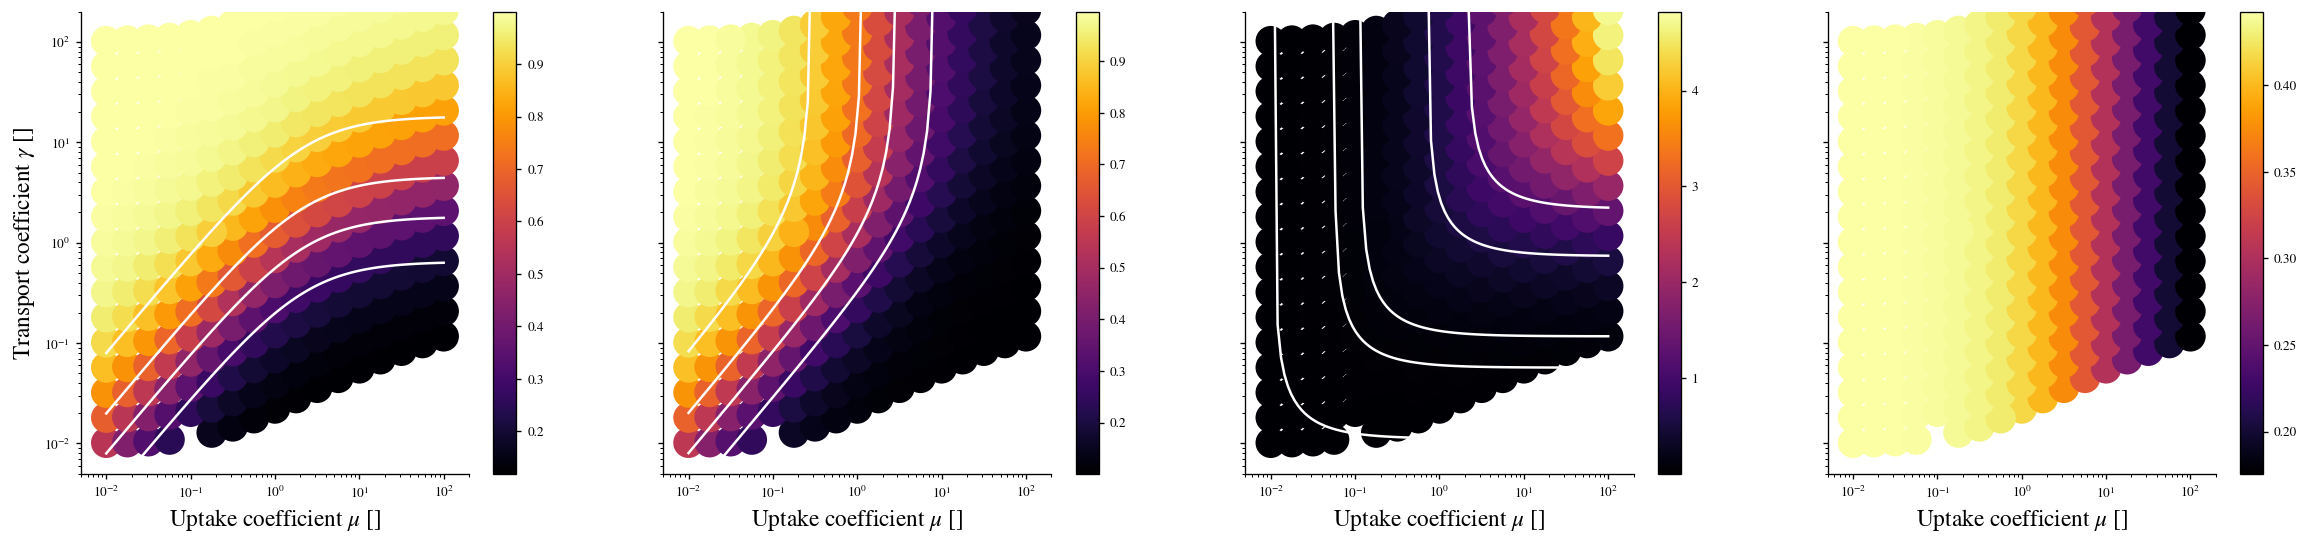

Resistance for sample is 2.024


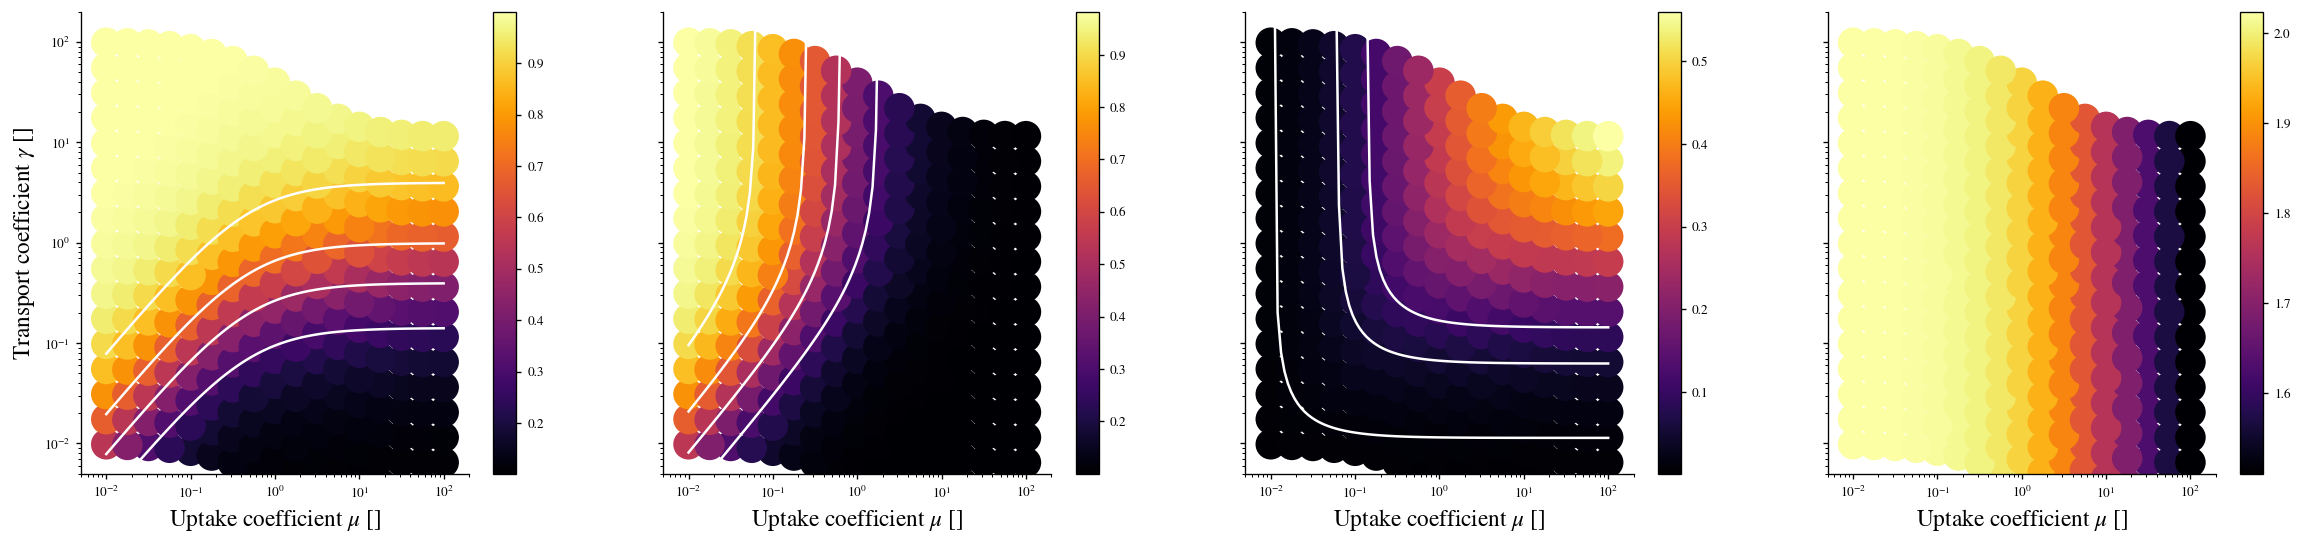

Resistance for sample is 5.922


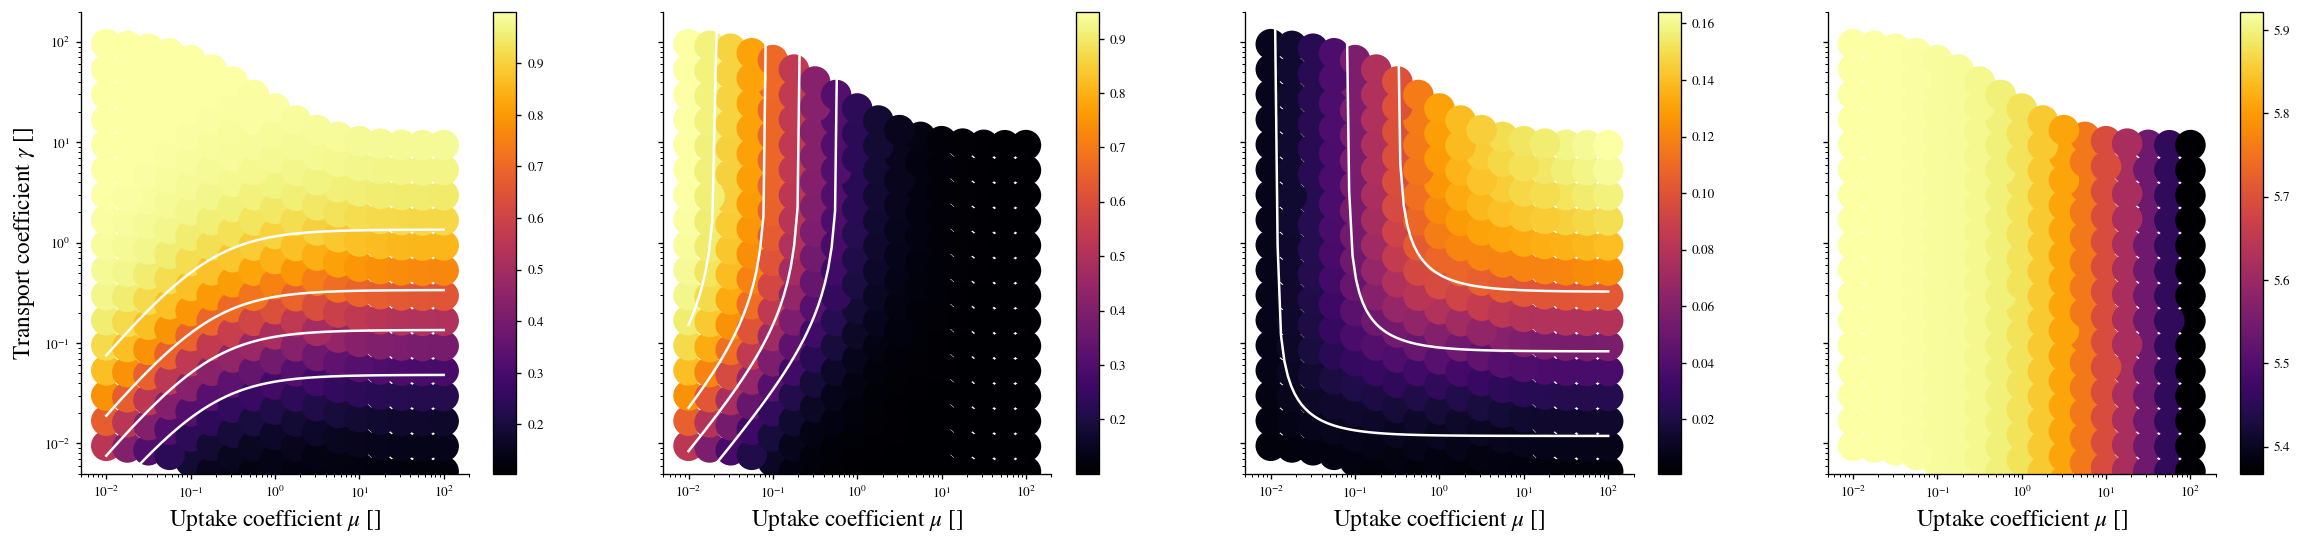

In [295]:
sample_ids = ["00000", "00331", "00076"]
path = lambda sample_id: "/home/andreasstillits/coding/MasterThesis/.phasespace" + f"/results_{sample_id}.csv" 


dfs = [load_dataframe(path(sample_id)) for sample_id in sample_ids]
mus = np.logspace(-2, 2, 100)

def chiis(mus: np.ndarray, chii: float, rho: float, chi_: float = 0.1) -> np.ndarray:
    rho = 1/rho
    return (chii-chi_) / (1 - chii) * (mus * rho)/(rho + mus)


def chims(mus: np.ndarray, chim: float, rho: float, chi_: float = 0.1) -> np.ndarray:
    rho = 1/rho
    denominator = rho * (1 - chim) / (chim-chi_) - mus
    mask = denominator > 0
    result = 1e3 * np.ones_like(mus)
    result[mask] = rho * mus[mask] / denominator[mask]
    return result

def ans(mus: np.ndarray, an: float, rho: float, chi_: float = 0.1) -> np.ndarray:
    rho = 1/rho
    denominator = (1 - chi_)/an - 1/rho - 1/mus
    mask = denominator > 0
    result = 1e3 * np.ones_like(mus)
    result[mask] = 1 / denominator[mask]
    return result

def _npy(df: pd.DataFrame, column: str) -> np.ndarray:
    return np.abs(df[column].to_numpy())

def _scales(ax: plt.Axes) -> None:
    despine(ax)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(5e-3, 2e2)
    ax.set_ylim(5e-3, 2e2)
    ax.set_xlabel(r"Uptake coefficient $\mu$ []", fontsize=fs)

for df in dfs:
    transport = _npy(df, "transport")
    absorption = _npy(df, "absorption")
    chii = _npy(df, "substomatal_mean")
    chim = _npy(df, "mesophyll_mean")
    variance = _npy(df, "mesophyll_var")
    cv = np.sqrt(variance) / chim
    an = _npy(df, "mesophyll_flux_sol") / _npy(df, "plug_area")
    resistances = (chii - chim) / an
    resistance = np.max(resistances)
    print(f"Resistance for sample is {resistance:.3f}")
    #
    S = 300

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(24, 5), sharey=True)
    sc1 = ax1.scatter(absorption, transport, c=chii, cmap=CMAP, marker="o", s=S)
    for chii_choice in (0.3, 0.5, 0.7, 0.9):
       ax1.plot(mus, chiis(mus, chii_choice, resistance), 'w-')
    _scales(ax1)
    ax1.set_ylabel(r"Transport coefficient $\gamma$ []", fontsize=fs)
    plt.colorbar(sc1, ax=ax1)
    

    sc2 = ax2.scatter(absorption, transport, c=chim, cmap=CMAP, marker="o", s=S)
    for chim_choice in (0.3, 0.5, 0.7, 0.9):
        ax2.plot(mus, chims(mus, chim_choice, resistance), 'w-')
    _scales(ax2)
    plt.colorbar(sc2, ax=ax2)

    sc3 = ax3.scatter(absorption, transport, c=an, cmap=CMAP, marker="o", s=S)
    for an_choice in [0.01, 0.05, 0.1, 0.5, 1.0]:
        ax3.plot(mus, ans(mus, an_choice, resistance), 'w-')
    _scales(ax3)
    plt.colorbar(sc3, ax=ax3)


    sc4 = ax4.scatter(absorption, transport, c=resistances, cmap=CMAP, marker="o", s=S)
    _scales(ax4)
    plt.colorbar(sc4, ax=ax4)

    plt.show()

## Plot IAS resistance for active / diffusion-only

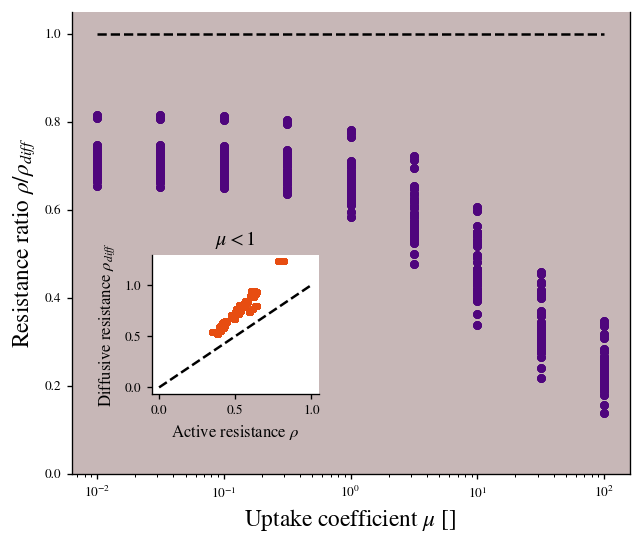

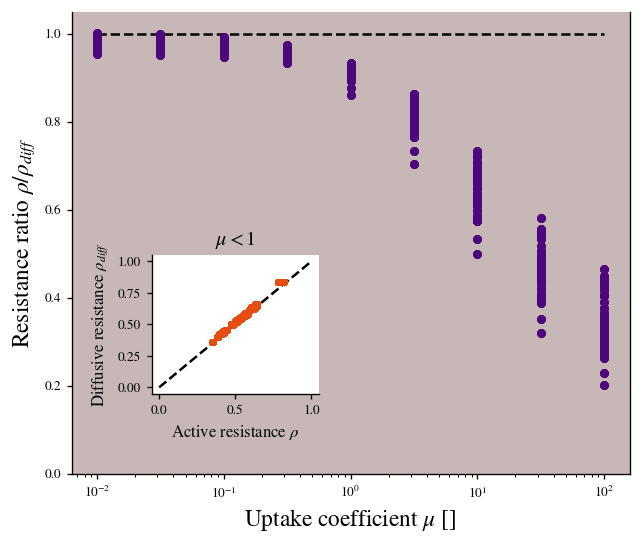

In [296]:
df = load_dataframe(paths.collection.require())
df_ = df[df["specifier"] == 0]

from mpl_toolkits.axes_grid1.inset_locator import inset_axes



def make_resistance_comparison_plot(df: pd.DataFrame, key: str, filename: str) -> None:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(df["absorption"], df["resistance_active"]/df[key], color="#4F067D")
    ax.set_facecolor(facecolor)
    ax.hlines(1, 0.01, 100, color="k", linestyle="--", zorder=0)
    ax.set_xscale("log")
    ax.set_ylim(0, 1.05)
    ax.set_xlabel(r"Uptake coefficient $\mu$ []", fontsize=fs)
    ax.set_ylabel(r"Resistance ratio $\rho/\rho_{diff}$", fontsize=fs)
    
    axins = inset_axes(ax, width="30%", height="30%", loc='lower left', borderpad=6)
    df_ = df[df["absorption"] < 1.0]
    axins.scatter(df_["resistance_active"], df_[key], color="#E74D11", s=10)
    axins.plot([0, 1.0], [0, 1.0], color="k", linestyle="--", zorder=0)
    despine(axins)
    axins.set_xlabel(r"Active resistance $\rho$", fontsize=fs-4)
    axins.set_ylabel(r"Diffusive resistance $\rho_{diff}$", fontsize=fs-4)
    axins.set_title(r"$\mu < 1$", fontsize=fs-2)
    
    save(fig, f"./saved/{filename}")
    plt.show()


make_resistance_comparison_plot(df_, "r_porous_mean", "active_comparison_dirichlet.pdf")
make_resistance_comparison_plot(df_, "r_neumann", "active_comparison_neumann.pdf")

## Transformation to reduced parameters

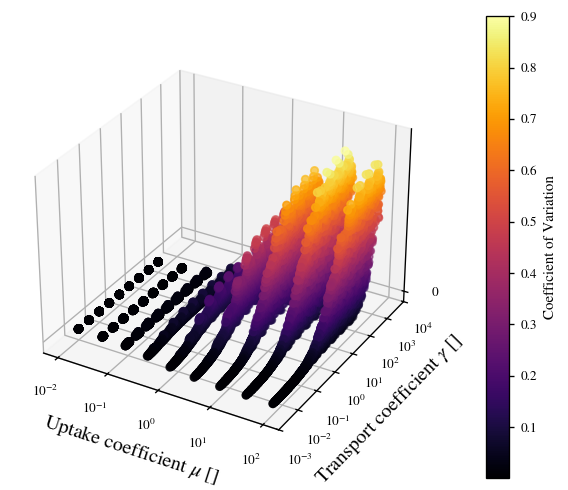

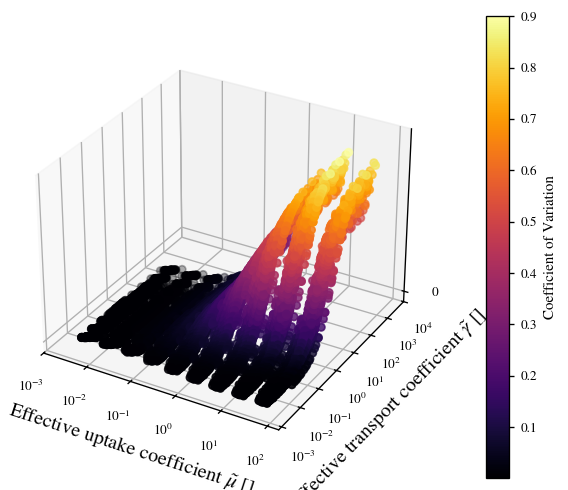

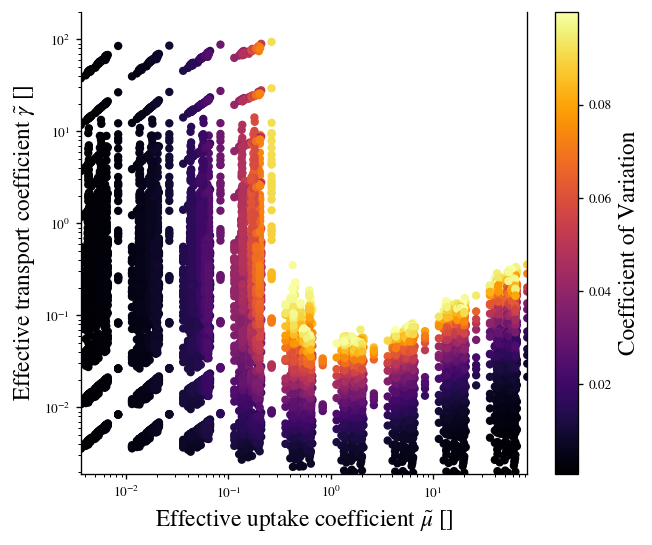

In [297]:
mu_eff = df["r_neumann_0"] * df["absorption"]
gamma_eff = df["r_neumann_0"] / (df["r_empty"] - 1 + 1/df["transport"])
key = "mesophyll_variation"

mu_eff_bounds = (mu_eff.min(), mu_eff.max())
gamma_eff_bounds = (gamma_eff.min(), 2e2)

def log3d_scatter(ax, x, y, z, *, base=10, logz=False, **scatter_kwargs):
    from matplotlib.ticker import FuncFormatter

    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)

    # mask = (x > 0) & (y > 0) & (z > 0)
    mask = np.ones_like(x, dtype=bool)

    if base == 10:
        (
            lx,
            ly,
            lz,
        ) = np.log10(x[mask]), np.log10(y[mask]), np.log10(z[mask])
        tick_label = lambda v: rf"$10^{{{int(v)}}}$"
    elif base == np.e:
        lx, ly, lz = np.log(x[mask]), np.log(y[mask]), np.log(z[mask])
        tick_label = lambda v: rf"$e^{{{int(v)}}}$"
    else:
        lx = np.log(x[mask]) / np.log(base)
        ly = np.log(y[mask]) / np.log(base)
        lz = np.log(z[mask]) / np.log(base)
        tick_label = lambda v: rf"${base}^{{{int(v)}}}$"

    if logz:
        sc = ax.scatter(lx, ly, lz, **scatter_kwargs)

        for axis, data in [
            (ax.xaxis, lx),
            (ax.yaxis, ly),
            (ax.zaxis, lz),
        ]:
            ticks = np.arange(np.floor(data.min()), np.ceil(data.max()) + 1)
            axis.axes.set_xticks(ticks) if axis is ax.xaxis else None

        ax.set_xticks(np.arange(np.floor(lx.min()), np.ceil(lx.max()) + 1))
        ax.set_yticks(np.arange(np.floor(ly.min()), np.ceil(ly.max()) + 1))
        ax.set_zticks(np.arange(np.floor(lz.min()), np.ceil(lz.max()) + 1))
    else:
        sc = ax.scatter(lx, ly, z[mask], **scatter_kwargs)

        for axis, data in [
            (ax.xaxis, lx),
            (ax.yaxis, ly),
           (ax.zaxis, z),
        ]:
            ticks = np.arange(np.floor(data.min()), np.ceil(data.max()) + 1)
            axis.axes.set_xticks(ticks) if axis is ax.xaxis else None

        ax.set_xticks(np.arange(np.floor(lx.min()), np.ceil(lx.max()) + 1))
        ax.set_yticks(np.arange(np.floor(ly.min()), np.ceil(ly.max()) + 1))
        ax.set_zticks(np.arange(np.floor(z.min()), np.ceil(z.max())))



    formatter = FuncFormatter(lambda val, pos: tick_label(val))
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)
    # ax.zaxis.set_major_formatter(formatter)

    return sc

# ON RAW PARAMETERS

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
sc = log3d_scatter(
    ax,
    df["absorption"],
    df["transport"],
    df[key],
    c=df[key],
    logz=False,
    cmap=CMAP,
    s=20,
)
ax.set_xlabel(r"Uptake coefficient $\mu$ []", fontsize=fs-2)
ax.set_ylabel(r"Transport coefficient $\gamma$ []", fontsize=fs-2)
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Coefficient of Variation")
save(fig, "./saved/mesophyll_variation_raw.pdf")
plt.show()


# ON EFFECTIVE PARAMETERS
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
sc = log3d_scatter(
    ax,
    mu_eff,
    gamma_eff,
    df[key],
    c=df[key],
    logz=False,
    cmap=CMAP,
    s=20,
)
ax.set_xlabel(r"Effective uptake coefficient $\tilde{\mu}$ []", fontsize=fs-2)
ax.set_ylabel(r"Effective transport coefficient $\tilde{\gamma}$ []", fontsize=fs-2)
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Coefficient of Variation")
save(fig, "./saved/mesophyll_variation_effective.pdf")
plt.show()

# CUT

mask = df[key] < 0.10

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(mu_eff[mask], gamma_eff[mask], c=df[key][mask], cmap=CMAP)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Coefficient of Variation", fontsize=fs)
ax.set_xlabel(r"Effective uptake coefficient $\tilde{\mu}$ []", fontsize=fs)
ax.set_ylabel(r"Effective transport coefficient $\tilde{\gamma}$ []", fontsize=fs)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(*mu_eff_bounds)
ax.set_ylim(*gamma_eff_bounds)
save(fig, "./saved/mesophyll_variation_effective_cut.pdf")
plt.show()

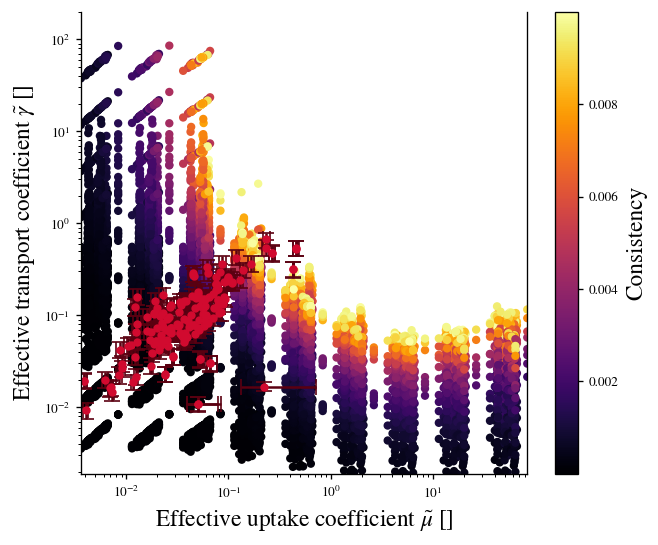

In [298]:
def plot_knauer_data(ax: plt.Axes) -> None:
    knauer = load_dataframe("/home/andreasstillits/coding/MasterThesis/scripts/data/derived/Knauer_filtered.csv")
    ax.errorbar(
        knauer["mu_eff"], 
        knauer["gamma_eff"], 
        xerr=[knauer["mu_eff_err16"], knauer["mu_eff_err84"]], 
        yerr=[knauer["gamma_eff_err16"], knauer["gamma_eff_err84"]], 
        fmt='o', 
        color='#D10A2F', 
        ecolor="#5B0011", 
        capsize=5
    )
    return
    


mask = (df["consistency"] < 0.01)


fig, ax = plt.subplots(figsize=(6, 5))

sc = ax.scatter(mu_eff[mask], gamma_eff[mask], c=df["consistency"][mask], cmap=CMAP)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Consistency", fontsize=fs)
ax.set_xlabel(r"Effective uptake coefficient $\tilde{\mu}$ []", fontsize=fs)
ax.set_ylabel(r"Effective transport coefficient $\tilde{\gamma}$ []", fontsize=fs)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(*mu_eff_bounds)
ax.set_ylim(*gamma_eff_bounds)

plot_knauer_data(ax)

save(fig, "./saved/consistency_effective_projection.pdf")

plt.show()



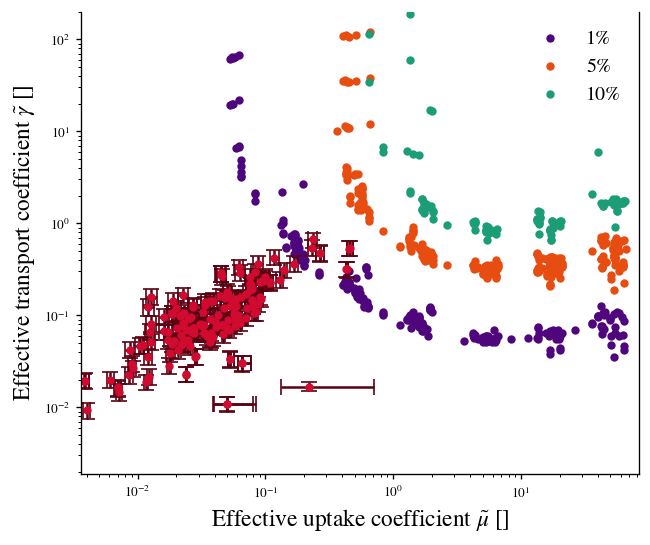

In [299]:
bounds = [
    (0.009, 0.01),
    (0.045, 0.05),
    (0.095, 0.10),
]
colors = ["#4F067D", "#E74D11", "#1B9E77"]

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_xlabel(r"Effective uptake coefficient $\tilde{\mu}$ []", fontsize=fs)
ax.set_ylabel(r"Effective transport coefficient $\tilde{\gamma}$ []", fontsize=fs)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(*mu_eff_bounds)
ax.set_ylim(*gamma_eff_bounds)

for bound, color in zip(bounds, colors):
    mask = (df["consistency"] >= bound[0]) & (df["consistency"] < bound[1])
    sc = ax.scatter(mu_eff[mask], gamma_eff[mask], color=color, label=f"{100*bound[1]:.0f}%")

ax.legend(fontsize=fs-2)
plot_knauer_data(ax)

save(fig, f"./saved/consistency_effective_projection_bounds.pdf")
plt.show()


## Errors from maintaining a scalar model

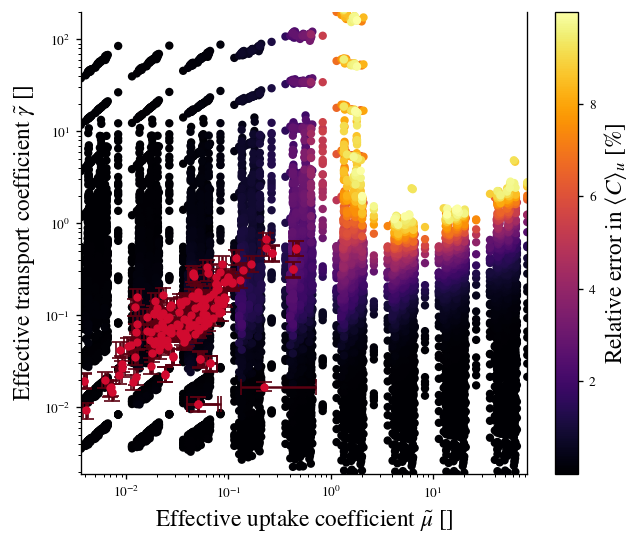

In [321]:
# ERRORS IN AVERAGE SURFACE CONCENTRATION

target = df["mesophyll_mean"]
predicted = df["compensation"] + (1 - df["compensation"])/(1 + df["absorption"]*(df["r_neumann"] + 1/df["transport"]))

error = 100 * np.abs(predicted - target) / target

df_new = pd.DataFrame({
    "mu_eff": mu_eff,
    "gamma_eff": gamma_eff,
    "error": error
})
df_new.sort_values("error", inplace=True)

mask = error < 10

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(df_new["mu_eff"][mask], df_new["gamma_eff"][mask], c=df_new["error"][mask], cmap=CMAP)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"Relative error in $\langle C \rangle_u$ [%]", fontsize=fs)
ax.set_xlabel(r"Effective uptake coefficient $\tilde{\mu}$ []", fontsize=fs)
ax.set_ylabel(r"Effective transport coefficient $\tilde{\gamma}$ []", fontsize=fs)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(*mu_eff_bounds)
ax.set_ylim(*gamma_eff_bounds)
plot_knauer_data(ax)

plt.show()



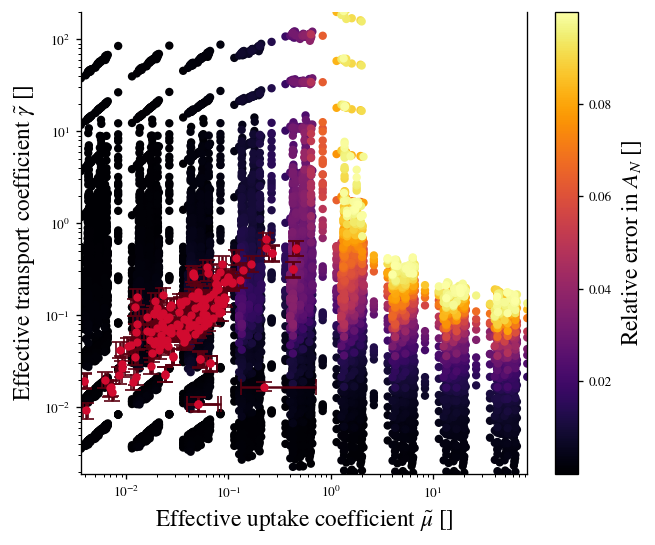

In [302]:
# ERRORS IN ASSIMILATION RATE


target = df["assimilation_rate"]
predicted = (1 - df["compensation"])/(1/df["absorption"] + df["r_neumann"] + 1/df["transport"])

error = np.abs(predicted - target) / target

df_new = pd.DataFrame({
    "mu_eff": mu_eff,
    "gamma_eff": gamma_eff,
    "error": error
})
df_new.sort_values("error", inplace=True)

mask = error < 0.10

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(df_new["mu_eff"][mask], df_new["gamma_eff"][mask], c=df_new["error"][mask], cmap=CMAP)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"Relative error in $A_N$ []", fontsize=fs)
ax.set_xlabel(r"Effective uptake coefficient $\tilde{\mu}$ []", fontsize=fs)
ax.set_ylabel(r"Effective transport coefficient $\tilde{\gamma}$ []", fontsize=fs)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(*mu_eff_bounds)
ax.set_ylim(*gamma_eff_bounds)
plot_knauer_data(ax)

plt.show()